(100, 2)


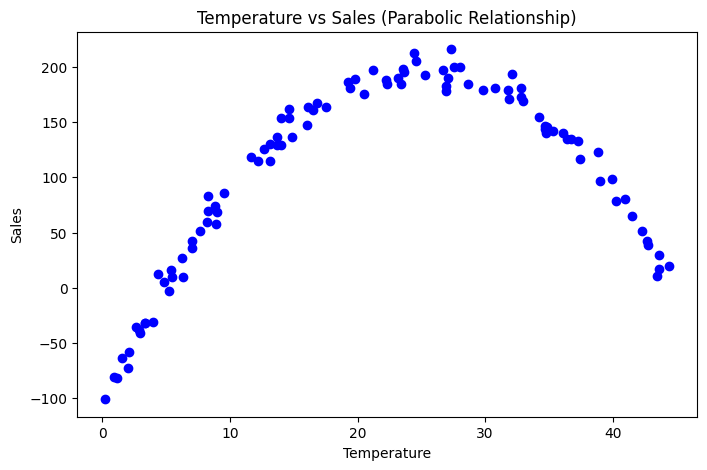

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# 1. data Creation
# Between 0 and 45 degrees (Includes extreme heats)
temperature = np.random.uniform(0, 45, 100)

# 2. Sales Formula (Parabolic)
# Formula logic: Increase up to a certain point, then decrease.
# - (temperature - 25)^2 expression creates a peak at 25 degrees, decreasing as you move right or left.
sales = 200 - 0.5 * (temperature - 25)**2 + np.random.normal(0, 10, 100)

# Let's make the data a DataFrame
df_poly = pd.DataFrame({'Temperature': temperature, 'Sales': sales})
# Let's see the shape of the data
print(df_poly.shape)
plt.figure(figsize=(8, 5))
plt.scatter(df_poly['Temperature'], df_poly['Sales'], color='blue')
plt.title('Temperature vs Sales (Parabolic Relationship)')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show()

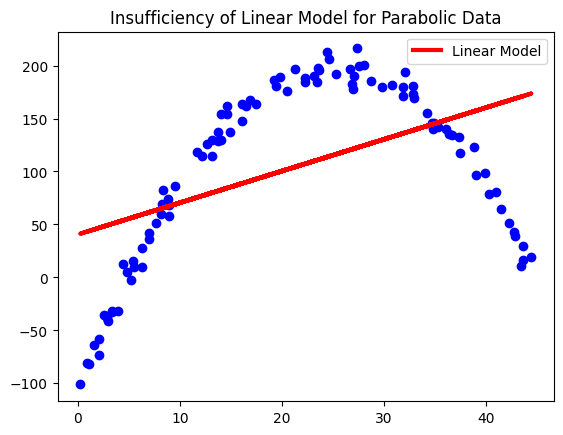

Linear Model R2 Score: 0.23


In [2]:
# Features
X = df_poly[['Temperature']]
y = df_poly['Sales']

# Linear Model
lin_model = LinearRegression()
lin_model.fit(X, y)

# Visualizing Linear Model
plt.scatter(X, y, color='blue')
plt.plot(X, lin_model.predict(X), color='red', linewidth=3, label='Linear Model')
plt.title("Insufficiency of Linear Model for Parabolic Data")
plt.legend()
plt.show()

print(f"Linear Model R2 Score: {r2_score(y, lin_model.predict(X)):.2f}")

In [3]:
# 2nd Degree Polynomial (x and x^2)
poly_features = PolynomialFeatures(degree=2)

# Transform X
X_poly = poly_features.fit_transform(X)

# Let's see the transformation (First 5 rows)
# The output will be in the order: [1 (bias), x (temperature), x^2 (temperature squared)].
print("Original X (First 3):\n", X.values[:3])
print("\nPolynomial X (First 3):\n", X_poly[:3])

Original X (First 3):
 [[16.85430535]
 [42.78214379]
 [32.93972738]]

Polynomial X (First 3):
 [[1.00000000e+00 1.68543053e+01 2.84067609e+02]
 [1.00000000e+00 4.27821438e+01 1.83031183e+03]
 [1.00000000e+00 3.29397274e+01 1.08502564e+03]]


In [4]:
# Train model with transformed data (X_poly)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_pred_poly = poly_model.predict(X_poly)

print("Polynomial Model Trained.")
print(f"Polynomial Model R2 Score: {r2_score(y, y_pred_poly):.2f}")

Polynomial Model Trained.
Polynomial Model R2 Score: 0.99


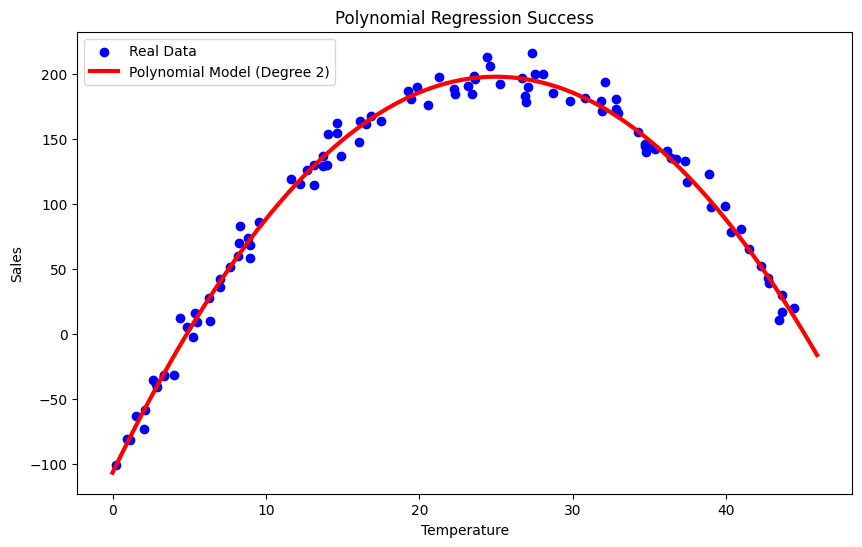

In [5]:
plt.figure(figsize=(10, 6))

# Real data points
plt.scatter(X, y, color='blue', label='Real Data')

# To draw the curve smoothly, let's create ordered test data
X_ordered = np.arange(0, 46, 0.1).reshape(-1, 1)
X_ordered_poly = poly_features.fit_transform(X_ordered) # DDon't forget the transformation!
y_ordered_pred = poly_model.predict(X_ordered_poly)

# Prediction curve
plt.plot(X_ordered, y_ordered_pred, color='red', linewidth=3, label='Polynomial Model (Degree 2)')

plt.title('Polynomial Regression Success')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [6]:
# Question: What will be the sales at 42 degrees? (The linear model would say high, let's see what this one says)
new_temperature = [[42]]

# FIRST transform
new_temperature_poly = poly_features.transform(new_temperature)
# THEN predict
prediction = poly_model.predict(new_temperature_poly)

print(f"Predicted sales at 42 degrees: {int(prediction[0])} units")

Predicted sales at 42 degrees: 55 units


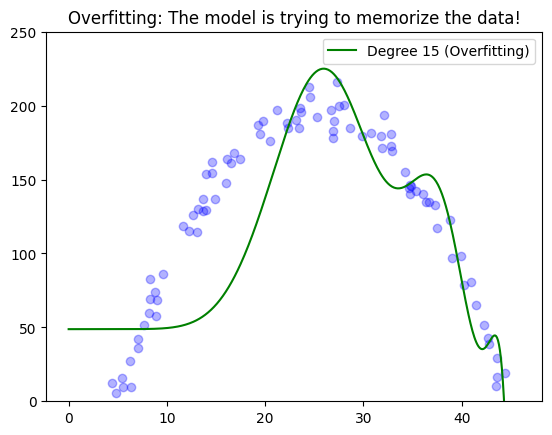

In [7]:
# Overfitting example
poly_high = PolynomialFeatures(degree=15)
X_high = poly_high.fit_transform(X)
model_high = LinearRegression()
model_high.fit(X_high, y)

# Visualization
X_ordered_high = poly_high.transform(X_ordered)
plt.scatter(X, y, color='blue', alpha=0.3)
plt.plot(X_ordered, model_high.predict(X_ordered_high), color='green', label='Degree 15 (Overfitting)')
plt.ylim(0, 250)
plt.legend()
plt.title("Overfitting: The model is trying to memorize the data!")
plt.show()